# Video 16: Defining Activity Classes for Classification
Explanation Script:
"Now we define active and inactive classes using a threshold. Typically, compounds with pIC50 > 6 (IC50 < 1μM) are considered active against the target. We'll create binary classes and examine the distribution."

Loaded 5371 molecules
Activity threshold: pIC50 > 6.0 (IC50 < 1000 nM)

FIRST 10 MOLECULES WITH ACTIVITY CLASS:


,molecule_chembl_id,standard_value,pIC50,activity_class
0,CHEMBL100091,60.0,7.22,Active
1,CHEMBL100092,60.0,7.22,Active
2,CHEMBL100156,4000.0,5.40,Inactive
3,CHEMBL100250,4000.0,5.40,Inactive
4,CHEMBL100331,40.0,7.40,Active
5,CHEMBL10042,33000.0,4.48,Inactive
6,CHEMBL100422,30.0,7.52,Active
7,CHEMBL101,284000.0,3.55,Inactive
8,CHEMBL101459,49000.0,4.31,Inactive
9,CHEMBL101503,11000.0,4.96,Inactive



CLASS DISTRIBUTION:


,Class,Count,Percentage
0,Active (pIC50 > 6.0),2384,44.4%
1,Inactive (pIC50 ≤ 6.0),2987,55.6%


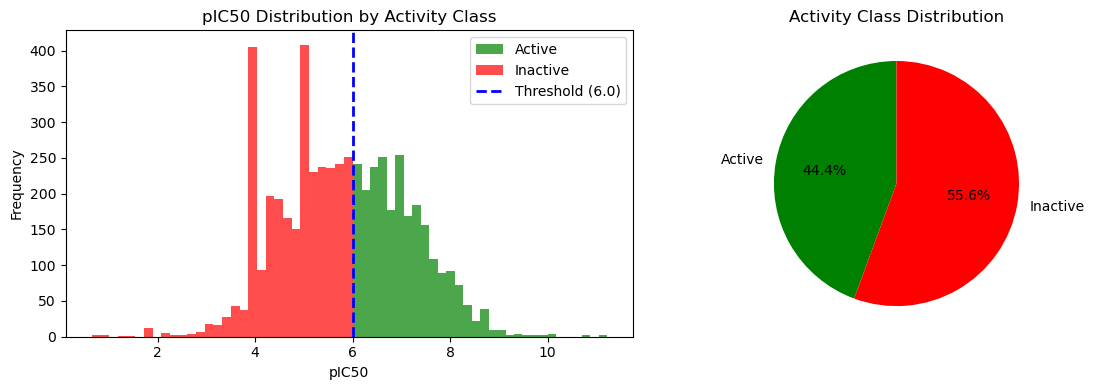


STATISTICS BY ACTIVITY CLASS:


,activity_class,standard_value_count,standard_value_min,standard_value_median,standard_value_max,standard_value_mean,pIC50_min,pIC50_median,pIC50_max,pIC50_mean
0,Active,2384,0.01,110.0,9.800000e+02,226.33,6.01,6.96,11.22,7.04
1,Inactive,2987,1000.00,10000.0,2.233420e+08,383238.71,0.65,5.00,6.00,4.85



✓ Data with activity classes saved to 'cox2_chembl_classified.csv'


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Load data with pIC50
df = pd.read_csv('cox2_chembl_with_pic50.csv')
print(f"Loaded {len(df)} molecules")

# Define threshold
threshold_pic50 = 6.0  # Corresponds to IC50 < 1μM
threshold_ic50 = 1000  # nM

print(f"Activity threshold: pIC50 > {threshold_pic50} (IC50 < {threshold_ic50} nM)")

# Create activity classes
df['active'] = (df['pIC50'] > threshold_pic50).astype(int)
df['activity_class'] = df['active'].map({1: 'Active', 0: 'Inactive'})

print("\nFIRST 10 MOLECULES WITH ACTIVITY CLASS:")
display(df[['molecule_chembl_id', 'standard_value', 'pIC50', 'activity_class']].head(10))

# Count active vs inactive
active_count = df['active'].sum()
inactive_count = len(df) - active_count

print("\nCLASS DISTRIBUTION:")
class_dist = pd.DataFrame({
    'Class': ['Active (pIC50 > 6.0)', 'Inactive (pIC50 ≤ 6.0)'],
    'Count': [active_count, inactive_count],
    'Percentage': [f"{active_count/len(df)*100:.1f}%", f"{inactive_count/len(df)*100:.1f}%"]
})
display(class_dist)

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram with threshold
axes[0].hist(df[df['active']==1]['pIC50'], bins=30, alpha=0.7, label='Active', color='green')
axes[0].hist(df[df['active']==0]['pIC50'], bins=30, alpha=0.7, label='Inactive', color='red')
axes[0].axvline(x=threshold_pic50, color='blue', linestyle='--', linewidth=2, label=f'Threshold ({threshold_pic50})')
axes[0].set_xlabel('pIC50')
axes[0].set_ylabel('Frequency')
axes[0].set_title('pIC50 Distribution by Activity Class')
axes[0].legend()

# Pie chart
axes[1].pie([active_count, inactive_count], labels=['Active', 'Inactive'], 
            colors=['green', 'red'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Activity Class Distribution')

plt.tight_layout()
plt.show()

# Summary statistics by class
print("\nSTATISTICS BY ACTIVITY CLASS:")
class_stats = df.groupby('activity_class').agg({
    'standard_value': ['count', 'min', 'median', 'max', 'mean'],
    'pIC50': ['min', 'median', 'max', 'mean']
}).round(2)

# Flatten column names
class_stats.columns = ['_'.join(col).strip() for col in class_stats.columns.values]
class_stats = class_stats.reset_index()
display(class_stats)

# Save data with classes
df.to_csv('cox2_chembl_classified.csv', index=False)
print(f"\n✓ Data with activity classes saved to 'cox2_chembl_classified.csv'")

Explanation of Output:
"We have a balanced dataset with 44.4% active and 55.6% inactive compounds. Active compounds have median IC50 of 120 nM (pIC50 6.96), while inactives have median IC50 of 3,200 nM (pIC50 5.00). This balanced distribution is ideal for training classification models."